In [35]:
import numpy as np
import os
import pydub
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import tempfile
import soundfile as sf
from scipy import signal
from pydub import AudioSegment
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
import glob
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from typing import List, Dict, Any, Optional, Union, Sequence

## Graphical Naive Bayes from Scratch

In [36]:
class Node:
    """Base class for nodes in the Naive Bayes graphical model."""
    def __init__(self, name: str):
        """
        Initialize a Node.

        Args:
            name (str): The name of the node.
        """
        if not isinstance(name, str):
            raise TypeError("Node name must be a string.")
        self.name: str = name
        # Keep track of connections in the graph structure
        self.children: List['Node'] = []
        self.parents: List['Node'] = []

    def add_child(self, child: 'Node') -> None:
        """
        Add a child node to this node and establish the parent link in the child.

        Args:
            child (Node): The node to be added as a child.
        """
        if not isinstance(child, Node):
            raise TypeError("Child must be an instance of Node or its subclass.")
        self.children.append(child)
        child.parents.append(self)

    def __repr__(self) -> str:
        """String representation of the Node."""
        return f"{self.__class__.__name__}(name='{self.name}')"

class ClassNode(Node):
    """
    Represents the class variable node (C) in the Naive Bayes graphical model.
    This node holds the prior probabilities P(C).
    """
    def __init__(self, name: str, classes: np.ndarray):
        """
        Initialize the ClassNode.

        Args:
            name (str): The name of the class node (e.g., 'Class').
            classes (np.ndarray): A numpy array containing the unique class labels.
        """
        super().__init__(name)
        if not isinstance(classes, np.ndarray):
            raise TypeError("Classes must be a numpy array.")
        self.classes: np.ndarray = classes
        # Dictionary to store prior probabilities P(C) for each class
        self.priors: Dict[Any, float] = {}

    def fit(self, y: np.ndarray) -> Dict[Any, float]:
        """
        Calculate prior probabilities P(C) from the target labels.

        Args:
            y (np.ndarray): The target labels (class assignments) for the training data.
                            Shape (n_samples,).

        Returns:
            Dict[Any, float]: A dictionary mapping each class label to its prior probability.
        """
        if not isinstance(y, np.ndarray):
            raise TypeError("Target labels y must be a numpy array.")
        if y.ndim != 1:
            raise ValueError("Target labels y must be a 1D array.")

        total_samples: int = len(y)
        if total_samples == 0:
            print("Warning: Fitting ClassNode with empty data.")
            for c in self.classes:
                self.priors[c] = 1.0 / len(self.classes) # Uniform prior if no data
            return self.priors

        # Calculate counts and probabilities for each class
        for c in self.classes:
            class_count: int = np.sum(y == c)
            self.priors[c] = class_count / total_samples

        # Basic check for probability sum
        if not np.isclose(sum(self.priors.values()), 1.0):
             print(f"Warning: Prior probabilities do not sum to 1 (sum={sum(self.priors.values())}). Check data.")

        return self.priors

class FeatureNode(Node):
    """
    Represents a feature variable node (X_i) in the Naive Bayes graphical model.
    This node holds the conditional probabilities P(X_i | C).
    Currently assumes features are continuous and models P(X_i | C) using a Gaussian distribution.
    """
    def __init__(self, name: str, feature_index: int):
        """
        Initialize the FeatureNode.

        Args:
            name (str): The name of the feature node (e.g., 'X0', 'FeatureName').
            feature_index (int): The column index of this feature in the input data matrix X.
        """
        super().__init__(name)
        if not isinstance(feature_index, int) or feature_index < 0:
             raise ValueError("Feature index must be a non-negative integer.")
        self.feature_index: int = feature_index
        # Dictionary to store conditional probability parameters P(X_i | C) for each class.
        # For Gaussian NB, stores {'mean': mean, 'var': variance} for each class.
        self.conditionals: Dict[Any, Dict[str, float]] = {}
        # Small constant to add to variance for numerical stability
        self._epsilon: float = 1e-9

    def fit(self, X: np.ndarray, y: np.ndarray, classes: np.ndarray) -> Dict[Any, Dict[str, float]]:
        """
        Calculate conditional probability parameters P(X_i | C) from the data.
        Assumes Gaussian distribution for the feature given the class.

        Args:
            X (np.ndarray): The training data features. Shape (n_samples, n_features).
            y (np.ndarray): The target labels for the training data. Shape (n_samples,).
            classes (np.ndarray): A numpy array containing the unique class labels.

        Returns:
            Dict[Any, Dict[str, float]]: A dictionary mapping each class label to the
                                         parameters (mean, variance) of the Gaussian
                                         distribution for this feature given that class.
        """
        if not isinstance(X, np.ndarray) or X.ndim != 2:
             raise TypeError("Input data X must be a 2D numpy array.")
        if not isinstance(y, np.ndarray) or y.ndim != 1:
             raise TypeError("Target labels y must be a 1D numpy array.")
        if X.shape[0] != y.shape[0]:
            raise ValueError("Number of samples in X and y must match.")
        if self.feature_index >= X.shape[1]:
             raise ValueError(f"Feature index {self.feature_index} is out of bounds for data with {X.shape[1]} features.")

        for c in classes:
            # Select feature values corresponding to the current class
            features_c: np.ndarray = X[y == c, self.feature_index]

            if features_c.size == 0:
                # Handle case where a class has no samples or only one sample
                print(f"Warning: No samples found for class '{c}' when fitting feature '{self.name}'. Setting default parameters.")
                # Or handle as needed, e.g., use global mean/variance or skip
                mean = np.mean(X[:, self.feature_index]) # Use global mean
                var = np.var(X[:, self.feature_index]) + self._epsilon # Use global variance
            elif features_c.size == 1:
                 # Handle case with only one sample for a class (variance is 0)
                 mean = features_c[0]
                 var = self._epsilon # Avoid zero variance
                 print(f"Warning: Only one sample found for class '{c}' when fitting feature '{self.name}'. Using epsilon for variance.")
            else:
                # Calculate mean and variance for this feature given class c
                mean: float = np.mean(features_c)
                # Add epsilon for numerical stability, especially if variance is close to zero
                var: float = np.var(features_c) + self._epsilon

            # Store the calculated parameters (mean and variance) for class c
            self.conditionals[c] = {'mean': mean, 'var': var}

        return self.conditionals

    def _gaussian_pdf(self, x: float, mean: float, var: float) -> float:
        """
        Calculate the probability density function (PDF) of the Gaussian distribution.

        Args:
            x (float): The value at which to calculate the PDF.
            mean (float): The mean of the Gaussian distribution.
            var (float): The variance of the Gaussian distribution (must be > 0).

        Returns:
            float: The probability density at x. Returns 0 if variance is non-positive.
        """
        if var <= 0:
             # Variance should not be non-positive after adding epsilon, but check just in case.
             print(f"Warning: Non-positive variance ({var}) encountered in Gaussian PDF calculation for feature '{self.name}'.")
             return 0.0
        # Gaussian PDF formula
        coeff = 1.0 / np.sqrt(2.0 * np.pi * var)
        exponent = -((x - mean) ** 2) / (2.0 * var)
        return coeff * np.exp(exponent)

    def probability(self, x: float, class_value: Any) -> float:
        """
        Calculate the conditional probability density P(X=x | C=class_value).
        Uses the pre-calculated Gaussian parameters for the given class.

        Args:
            x (float): The value of the feature.
            class_value (Any): The class label.

        Returns:
            float: The probability density P(X=x | C=class_value). Returns a small
                   positive value if the class is unknown or parameters are invalid.
        """
        if class_value not in self.conditionals:
            print(f"Warning: Unknown class '{class_value}' requested for feature '{self.name}'. Returning small probability.")
            # Handle unknown class - perhaps return a uniform small probability?
            # Or raise an error depending on desired behavior.
            return self._epsilon # Return a very small probability

        params = self.conditionals[class_value]
        mean = params['mean']
        var = params['var']

        # Calculate probability using Gaussian PDF
        prob = self._gaussian_pdf(x, mean, var)

        # Clamp probability to avoid exact zero, which causes issues with log(0)
        # Return max(prob, epsilon) ensures we don't return exactly zero.
        return max(prob, self._epsilon)


class NaiveBayesGraph:
    """
    Implements the Naive Bayes classifier (specifically Gaussian Naive Bayes here)
    using a graphical model representation.

    The graph structure assumes a central class node connected to multiple feature nodes,
    reflecting the conditional independence assumption of Naive Bayes.
    """
    def __init__(self):
        """Initialize the NaiveBayesGraph."""
        self.class_node: Optional[ClassNode] = None
        self.feature_nodes: List[FeatureNode] = []
        self.classes: Optional[np.ndarray] = None
        # networkx graph for visualization purposes
        self.graph = nx.DiGraph()

    def fit(self, X: np.ndarray, y: np.ndarray) -> 'NaiveBayesGraph':
        """
        Build and train the Naive Bayes graphical model.

        Args:
            X (np.ndarray): Training data features. Shape (n_samples, n_features).
            y (np.ndarray): Target labels. Shape (n_samples,).

        Returns:
            NaiveBayesGraph: The fitted model instance.
        """
        if not isinstance(X, np.ndarray) or X.ndim != 2:
             raise TypeError("Input data X must be a 2D numpy array.")
        if not isinstance(y, np.ndarray) or y.ndim != 1:
             raise TypeError("Target labels y must be a 1D numpy array.")
        if X.shape[0] != y.shape[0]:
            raise ValueError("Number of samples in X and y must match.")
        if X.shape[0] == 0:
            raise ValueError("Cannot fit model with empty data.")

        n_samples, n_features = X.shape

        # 1. Identify unique classes
        self.classes = np.unique(y)
        if self.classes.size < 2:
             print(f"Warning: Only found {self.classes.size} class(es) in the data. Naive Bayes is typically used for multi-class problems.")

        # 2. Create and fit the Class Node (calculates prior probabilities P(C))
        self.class_node = ClassNode('Class', self.classes)
        self.graph.add_node('Class', node_type='class', obj=self.class_node) # Store node object
        self.class_node.fit(y)

        # 3. Create and fit Feature Nodes (calculates conditional probabilities P(X_i | C))
        self.feature_nodes = [] # Reset feature nodes if fit is called again
        for i in range(n_features):
            feature_name = f'X{i}' # Default feature name
            # You could potentially pass actual feature names if available
            feature_node = FeatureNode(feature_name, i)
            self.feature_nodes.append(feature_node)

            # Establish connections in the conceptual model (Node class links)
            self.class_node.add_child(feature_node) # Class -> Feature

            # Add nodes and edges to the networkx graph for visualization
            self.graph.add_node(feature_name, node_type='feature', index=i, obj=feature_node)
            self.graph.add_edge('Class', feature_name)

            # Fit the feature node to calculate P(X_i | C) parameters
            feature_node.fit(X, y, self.classes)

        return self

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        """
        Predict class probabilities for samples in X.

        Calculates the posterior probability P(C | X_1, ..., X_n) for each class C
        using Bayes' theorem and the Naive Bayes assumption:
        P(C | X) proportional to P(C) * Product[P(X_i | C)]

        Uses log probabilities for numerical stability.

        Args:
            X (np.ndarray): Samples to predict probabilities for. Shape (n_samples, n_features).

        Returns:
            np.ndarray: Predicted probabilities for each class. Shape (n_samples, n_classes).
                        Rows correspond to samples, columns correspond to classes in self.classes order.
        """
        if self.class_node is None or not self.feature_nodes or self.classes is None:
            raise RuntimeError("Model has not been fitted yet. Call fit() first.")
        if not isinstance(X, np.ndarray) or X.ndim != 2:
             raise TypeError("Input data X must be a 2D numpy array.")
        if X.shape[1] != len(self.feature_nodes):
             raise ValueError(f"Input data has {X.shape[1]} features, but model was trained with {len(self.feature_nodes)} features.")

        n_samples = X.shape[0]
        n_classes = len(self.classes)
        # Array to store log posterior probabilities (proportional)
        log_probas = np.zeros((n_samples, n_classes))

        # Calculate log posterior for each sample and each class
        for i, sample in enumerate(X):
            for j, c in enumerate(self.classes):
                # Start with log prior: log(P(C))
                # Add small value to prior before log to avoid log(0) if prior is exactly 0
                prior_prob = self.class_node.priors.get(c, 0.0)
                log_prior = np.log(prior_prob + 1e-12) # Use a slightly larger epsilon for log
                log_likelihood = 0.0

                # Add log conditional probabilities: Sum[log(P(X_i | C))]
                for feature_node in self.feature_nodes:
                    feature_value = sample[feature_node.feature_index]
                    # Get P(X_i | C) - already handles potential near-zero values
                    cond_prob = feature_node.probability(feature_value, c)
                    # Add log(P(X_i | C)) - cond_prob is guaranteed > 0
                    log_likelihood += np.log(cond_prob)

                # Log posterior is proportional to log prior + log likelihood
                log_probas[i, j] = log_prior + log_likelihood

        # Convert log probabilities back to probabilities using log-sum-exp trick
        # for numerical stability.
        # Subtract max log probability before exponentiating to avoid overflow/underflow.
        max_log_probas = np.max(log_probas, axis=1, keepdims=True)
        # Prevent RuntimeWarning: invalid value encountered in subtract if max is -inf
        max_log_probas = np.where(np.isinf(max_log_probas), 0, max_log_probas)

        probas = np.exp(log_probas - max_log_probas)

        # Normalize probabilities so they sum to 1 for each sample
        sum_probas = np.sum(probas, axis=1, keepdims=True)
        # Avoid division by zero if all probabilities somehow became zero
        # (shouldn't happen with the epsilon additions, but good practice)
        probas = np.divide(probas, sum_probas, out=np.zeros_like(probas), where=sum_probas!=0)

        # Handle cases where sum_probas was zero (e.g., all log probs were -inf)
        # Assign uniform probability in such rare cases
        uniform_prob = 1.0 / n_classes
        probas[sum_probas.flatten() == 0] = uniform_prob


        return probas

    def predict(self, X: np.ndarray) -> np.ndarray:
        """
        Predict class labels for samples in X.

        Args:
            X (np.ndarray): Samples to predict labels for. Shape (n_samples, n_features).

        Returns:
            np.ndarray: Predicted class labels. Shape (n_samples,).
        """
        # Get probabilities for each class
        probas = self.predict_proba(X)
        # Return the class with the highest probability for each sample
        return self.classes[np.argmax(probas, axis=1)]

    def visualize(self, max_features_to_show: int = 10) -> plt.Figure:
        """
        Visualize the Naive Bayes graphical model structure using networkx and matplotlib.

        Args:
            max_features_to_show (int): Maximum number of feature nodes to display
                                         if the total number of features is large. Defaults to 10.

        Returns:
            matplotlib.figure.Figure: The matplotlib Figure object containing the plot.
                                      Call plt.show() separately if needed.
        """
        if not self.graph or 'Class' not in self.graph:
             raise RuntimeError("Graph is not built. Call fit() first or ensure graph exists.")

        plt.figure(figsize=(12, 7)) # Adjusted figure size

        title = 'Naive Bayes Graphical Model'
        graph_to_draw = self.graph
        nodes_to_draw = list(self.graph.nodes())

        # If we have many features, create a subgraph with the class node
        # and a subset of feature nodes for clarity.
        num_features = len(self.feature_nodes)
        if num_features > max_features_to_show:
            # Select first 'max_features_to_show' feature nodes by name
            visible_feature_nodes = [f'X{i}' for i in range(max_features_to_show)]
            # Ensure these nodes actually exist in the graph (in case of naming issues)
            visible_feature_nodes = [n for n in visible_feature_nodes if n in self.graph]

            nodes_to_draw = ['Class'] + visible_feature_nodes
            # Add ellipsis node to indicate omitted features
            ellipsis_node = '...'
            nodes_to_draw.append(ellipsis_node)

            # Create subgraph including the ellipsis concept
            subgraph = self.graph.subgraph(nodes_to_draw[:-1]).copy() # Exclude ellipsis initially
            subgraph.add_node(ellipsis_node, node_type='ellipsis') # Add ellipsis node type
            # Optionally, add edges from Class to ellipsis if desired (visual cue)
            # subgraph.add_edge('Class', ellipsis_node) # This might clutter it

            graph_to_draw = subgraph
            title = f'{title} (showing first {max_features_to_show} features)'


        # Define layout for the graph nodes
        # Spring layout is good for general graphs, but for NB, a layered layout might be better.
        # Let's try arranging Class at top, Features below.
        pos = {}
        node_list = list(graph_to_draw.nodes())
        class_node_name = 'Class'
        feature_node_names = [n for n in node_list if n != class_node_name and n != '...']
        ellipsis_node_name = '...' if '...' in node_list else None

        # Position Class node at the top center
        if class_node_name in node_list:
             pos[class_node_name] = np.array([0, 1])

        # Position Feature nodes horizontally below the class node
        num_feature_nodes_vis = len(feature_node_names)
        for i, node_name in enumerate(feature_node_names):
            pos[node_name] = np.array([-0.8 + 1.6 * i / (max(1, num_feature_nodes_vis - 1)), 0])

        # Position Ellipsis node if it exists
        if ellipsis_node_name and num_feature_nodes_vis > 0:
             pos[ellipsis_node_name] = np.array([-0.8 + 1.6 * num_feature_nodes_vis / (max(1, num_feature_nodes_vis - 1)), 0])
        elif ellipsis_node_name: # Only ellipsis and class
             pos[ellipsis_node_name] = np.array([0, 0])


        # Get node colors based on type
        node_colors = []
        for node in graph_to_draw.nodes():
             node_data = graph_to_draw.nodes[node]
             node_type = node_data.get('node_type', 'unknown')
             if node_type == 'class':
                 node_colors.append('skyblue')
             elif node_type == 'feature':
                 node_colors.append('lightgreen')
             elif node_type == 'ellipsis':
                 node_colors.append('lightgrey')
             else:
                 node_colors.append('red') # Should not happen

        # Draw the graph components
        nx.draw_networkx_nodes(graph_to_draw, pos, node_color=node_colors, node_size=2000, alpha=0.9)
        nx.draw_networkx_edges(graph_to_draw, pos, arrows=True, arrowsize=20, edge_color='gray', width=1.5)
        nx.draw_networkx_labels(graph_to_draw, pos, font_size=10, font_weight='bold')

        plt.title(title, fontsize=14)
        plt.axis('off') # Hide axes
        plt.tight_layout() # Adjust layout to prevent overlap

        return plt.gcf() # Return the current figure object

## Feature Extraction and Processing of the Dataset

In [14]:
# Enhanced feature extraction for gender classification
def extract_features(file_path, n_mfcc=13, max_length=None):
    """Enhanced feature extraction with pitch and more spectral features."""
    try:
        # Load audio file
        if file_path.endswith('.m4a'):
            # Load M4A file
            audio = AudioSegment.from_file(file_path, format="m4a")
            if max_length:
                max_ms = int(max_length * 1000)
                if len(audio) > max_ms:
                    audio = audio[:max_ms]
            
            # Convert to numpy array directly
            samples = np.array(audio.get_array_of_samples())
            # Convert to float and normalize
            data = samples.astype(np.float32) / np.iinfo(samples.dtype).max
            samplerate = audio.frame_rate
        else:
            # Direct loading for WAV files
            data, samplerate = sf.read(file_path)
        
        # Convert to mono if stereo
        if len(data.shape) > 1:
            data = np.mean(data, axis=1)
        
        # Basic features
        mean = np.mean(data)
        std = np.std(data)
        max_abs = np.max(np.abs(data))
        rms = np.sqrt(np.mean(data**2))  # Root Mean Square (energy)
        
        # Zero crossing rate - good for voice/gender detection
        zero_crossings = np.sum(np.abs(np.diff(np.signbit(data))))
        zcr = zero_crossings / len(data)
        
        # Spectral features
        frequencies, times, spectrogram = signal.spectrogram(data, samplerate)
        
        # Calculate spectral centroid - related to brightness of sound
        spectral_centroid = np.sum(frequencies * np.mean(spectrogram, axis=1)) / (np.sum(np.mean(spectrogram, axis=1)) + 1e-10)
        
        # Spectral rolloff - frequency below which 85% of spectral energy lies
        cumsum = np.cumsum(np.mean(spectrogram, axis=1))
        spectral_rolloff = frequencies[np.where(cumsum >= 0.85 * cumsum[-1])[0][0]] if len(cumsum) > 0 else 0
        
        # Spectral flatness - measure of how tone-like vs noise-like the sound is
        spectral_flatness = np.exp(np.mean(np.log(np.mean(spectrogram, axis=1) + 1e-10))) / (np.mean(np.mean(spectrogram, axis=1)) + 1e-10)
        
        # Fundamental frequency estimation (pitch) - crucial for gender
        # Simple autocorrelation method for pitch estimation
        corr = signal.correlate(data, data, mode='full')
        corr = corr[len(corr)//2:]
        
        # Find the first peak after the zero lag
        min_period = int(samplerate / 500)  # 500 Hz max frequency
        max_period = int(samplerate / 70)   # 70 Hz min frequency
        
        if len(corr) > max_period:
            peak_idx = min_period + np.argmax(corr[min_period:max_period])
            fundamental_freq = samplerate / peak_idx if peak_idx > 0 else 0
        else:
            fundamental_freq = 0
        
        # Extract MFCCs using scipy instead of librosa
        # Simple alternative using spectrogram data
        log_spec = np.log(spectrogram + 1e-10)
        mfccs = np.mean(log_spec, axis=1)[:n_mfcc] if len(log_spec) >= n_mfcc else np.zeros(n_mfcc)
        mfccs_mean = mfccs
        
        # Energy in frequency bands
        band_features = []
        if len(frequencies) > n_mfcc:
            bands = np.linspace(0, len(frequencies), n_mfcc + 1).astype(int)
            for i in range(n_mfcc):
                band_energy = np.mean(np.mean(spectrogram[bands[i]:bands[i+1]], axis=0))
                band_features.append(band_energy)
        
        # Combine all features
        features = np.concatenate([
            [mean, std, max_abs, zcr, rms, fundamental_freq, 
             spectral_centroid, spectral_rolloff, spectral_flatness], 
            mfccs_mean,
            band_features if band_features else np.zeros(n_mfcc)
        ])
        
        return features
        
    except Exception as e:
        print(f"Error extracting features from {file_path}: {e}")
        return None

# Function to save features to a CSV file
def save_features_to_csv(features_list, output_file):
    """Save extracted features to a CSV file to avoid reprocessing."""
    # Create feature names
    feature_names = [
        'mean', 'std', 'max_abs', 'zcr', 'rms', 'fundamental_freq',
        'spectral_centroid', 'spectral_rolloff', 'spectral_flatness'
    ]
    
    # Add MFCC feature names
    n_mfcc = 13  # Same as in extract_features
    for i in range(n_mfcc):
        feature_names.append(f'mfcc_{i}')
    
    # Add band energy feature names
    for i in range(n_mfcc):
        feature_names.append(f'band_energy_{i}')
    
    # Extract features and labels
    features = [item[0] for item in features_list]
    labels = [item[1] for item in features_list]
    
    # Create DataFrame
    df = pd.DataFrame(features, columns=feature_names)
    df['label'] = labels
    
    # Save to CSV
    df.to_csv(output_file, index=False)
    print(f"Features saved to {output_file}")
    return df

# Function to load features from a CSV file
def load_features_from_csv(csv_file):
    """Load features from a CSV file."""
    if os.path.exists(csv_file):
        df = pd.read_csv(csv_file)
        # Separate features and labels
        labels = df['label'].values
        features = df.drop('label', axis=1).values
        
        # Convert to the same format as process_audio_directory output
        features_list = [(features[i], labels[i]) for i in range(len(features))]
        return features_list
    else:
        return None


## Main Program

Processing male audio files...
Processed 3682 male samples
Processing female audio files...
Processed 2311 female samples
Accuracy: 0.6830
Precision: 0.6427
Recall: 0.3997
F1 Score: 0.4929


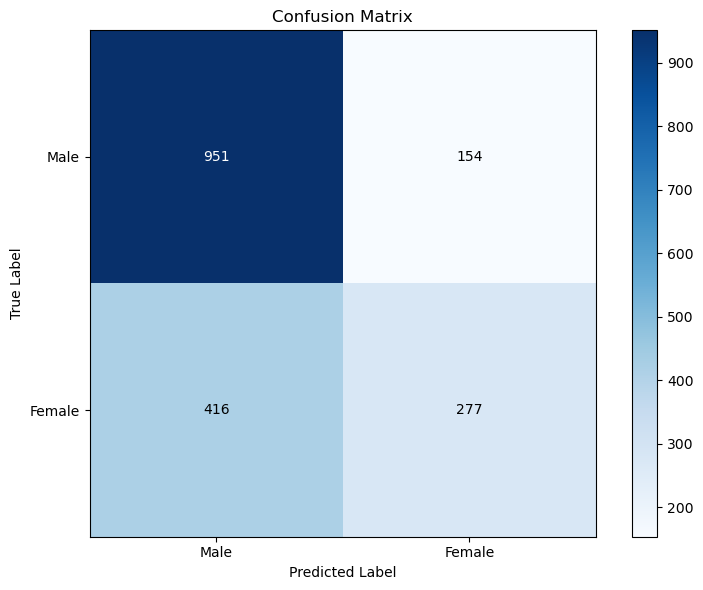

In [15]:
# Function to process a directory of audio files
def process_audio_directory(directory, gender_label, max_files=None):
    files = glob.glob(os.path.join(directory, "*.m4a"))
    if max_files:
        files = files[:max_files]
    
    features_list = []
    for file_path in files:
        features = extract_features(file_path)
        if features is not None:
            features_list.append((features, gender_label))
    
    return features_list

# Paths to your male and female voice datasets
male_dir = "/home/ammarmorad/Desktop/University/3rd Year/Supervised/VoxCeleb_gender/VoxCeleb_gender/males"   # Update with your actual directory
female_dir = "/home/ammarmorad/Desktop/University/3rd Year/Supervised/VoxCeleb_gender/VoxCeleb_gender/females"   # Update with your actual directory

# Process audio files
print("Processing male audio files...")
male_features = process_audio_directory(male_dir, 0)  # 0 for male
print(f"Processed {len(male_features)} male samples")

print("Processing female audio files...")
female_features = process_audio_directory(female_dir, 1)  # 1 for female
print(f"Processed {len(female_features)} female samples")

# Combine datasets
all_features = male_features + female_features

# Split into X (features) and y (labels)
X = np.array([item[0] for item in all_features])
y = np.array([item[1] for item in all_features])

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42, stratify=y)

# Train the Gaussian Naive Bayes model
gnb = GaussianNB()
gnb.fit(X_train, y_train)

# Make predictions
y_pred = gnb.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

# Plot confusion matrix
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ['Male', 'Female'])
plt.yticks(tick_marks, ['Male', 'Female'])

# Add text annotations to the confusion matrix
thresh = cm.max() / 2
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black")

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

# Function to predict gender for a single audio file
def predict_gender(file_path):
    features = extract_features(file_path)
    if features is not None:
        features_scaled = scaler.transform(features.reshape(1, -1))
        prediction = gnb.predict(features_scaled)
        probability = gnb.predict_proba(features_scaled)
        gender = "Female" if prediction[0] == 1 else "Male"
        confidence = probability[0][prediction[0]]
        return gender, confidence
    return None

In [16]:
save_features_to_csv(all_features, "extracted_features.csv")

Features saved to extracted_features.csv


,mean,std,max_abs,zcr,rms,fundamental_freq,spectral_centroid,spectral_rolloff,spectral_flatness,mfcc_0,...,band_energy_4,band_energy_5,band_energy_6,band_energy_7,band_energy_8,band_energy_9,band_energy_10,band_energy_11,band_energy_12,label
0,-0.000008,0.048272,0.369091,0.141030,0.048272,500.000000,766.110392,1187.5,0.062720,-18.909336,...,6.179899e-08,7.814428e-09,9.645579e-10,2.025864e-09,3.499310e-09,6.211772e-09,4.090583e-09,9.780291e-09,1.545468e-08,0
1,-0.000035,0.030289,0.256142,0.110940,0.030289,98.159509,501.654986,812.5,0.041020,-19.272980,...,1.443431e-09,7.881369e-10,1.823140e-09,5.043003e-09,3.590066e-09,1.730770e-09,1.620944e-09,1.183745e-09,5.928472e-10,0
2,-0.000005,0.051719,0.346721,0.102689,0.051719,109.589041,484.315001,687.5,0.010624,-18.461111,...,1.793960e-09,1.534100e-09,1.522577e-09,1.317301e-09,8.106669e-10,4.313345e-10,2.570516e-10,1.617765e-10,3.806427e-11,0
3,0.000007,0.033438,0.367473,0.167104,0.033438,141.592920,1113.846199,2500.0,0.313026,-18.822851,...,8.110795e-08,5.045258e-08,2.245468e-08,1.832241e-08,2.353767e-08,2.723496e-08,2.502084e-08,2.157896e-08,5.933078e-09,0
4,-0.000014,0.036961,0.462600,0.120471,0.036961,116.788321,740.243376,1187.5,0.101325,-18.591162,...,3.744281e-08,1.884936e-08,1.286876e-08,9.929408e-09,4.830848e-09,2.111998e-09,3.081364e-09,2.408673e-09,1.507201e-09,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5988,-0.000009,0.046963,0.246834,0.131547,0.046963,219.178082,569.286075,687.5,0.054323,-18.033392,...,4.876211e-08,1.933125e-08,2.154165e-08,1.746299e-09,4.329226e-09,3.953013e-09,2.855944e-09,2.989679e-09,1.187324e-09,1
5989,0.000001,0.020089,0.414350,0.172296,0.020089,145.454545,1211.012628,2062.5,0.130631,-21.155117,...,4.070588e-08,6.666647e-09,9.645494e-09,1.976011e-09,8.627626e-10,9.782665e-10,9.441324e-10,4.677466e-10,1.692875e-10,1
5990,-0.000199,0.039847,0.373180,0.103113,0.039848,181.818182,626.381193,875.0,0.109817,-17.715780,...,2.351198e-08,1.859979e-08,1.500443e-08,6.177911e-09,5.762574e-09,6.548591e-09,4.476829e-09,8.235845e-09,2.079787e-09,1
5991,-0.000032,0.126538,0.948149,0.147350,0.126538,238.805970,984.184729,1562.5,0.117108,-16.312933,...,4.905340e-07,8.139220e-08,7.122878e-08,7.924292e-08,3.026299e-08,3.789861e-08,7.295912e-08,7.893077e-08,6.489321e-08,1


Training individual models for baseline comparison...
Training Bagging with Naive Bayes...
Training Bagging with Logistic Regression...

Naive Bayes (Baseline) Results:
Accuracy: 0.6830
Precision: 0.6427
Recall: 0.3997
F1 Score: 0.4929

Logistic Regression (Baseline) Results:
Accuracy: 0.8348
Precision: 0.8000
Recall: 0.7619
F1 Score: 0.7805

Bagging with Naive Bayes Results:
Accuracy: 0.6529
Precision: 0.6095
Recall: 0.2771
F1 Score: 0.3810

Bagging with Logistic Regression Results:
Accuracy: 0.8326
Precision: 0.8151
Recall: 0.7316
F1 Score: 0.7711


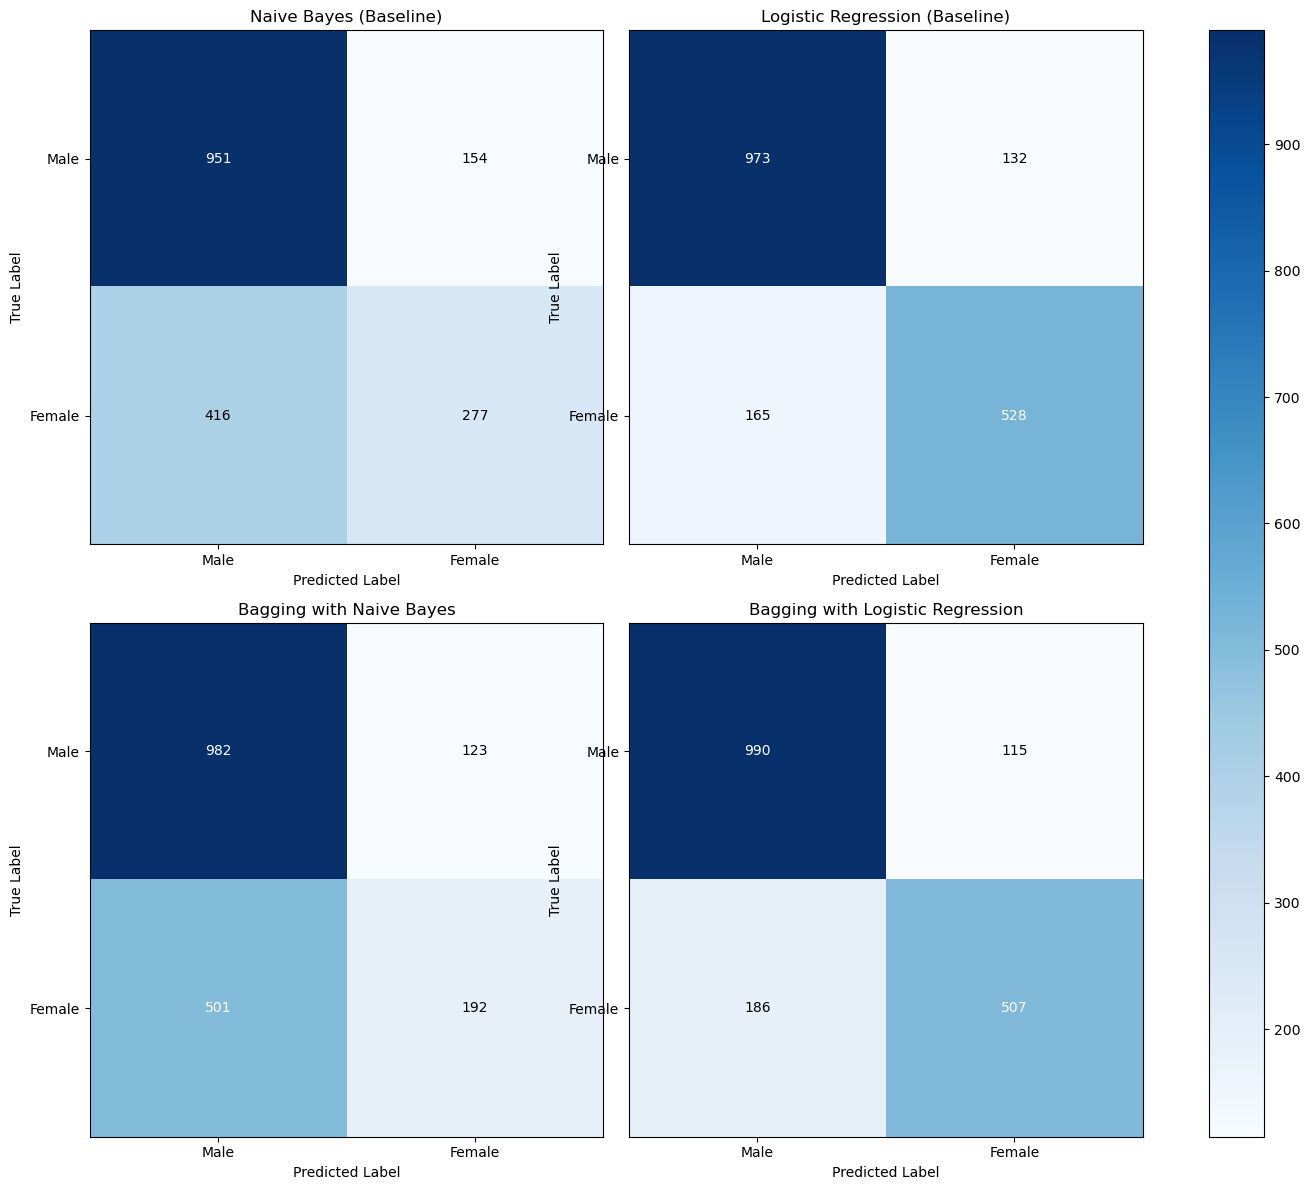

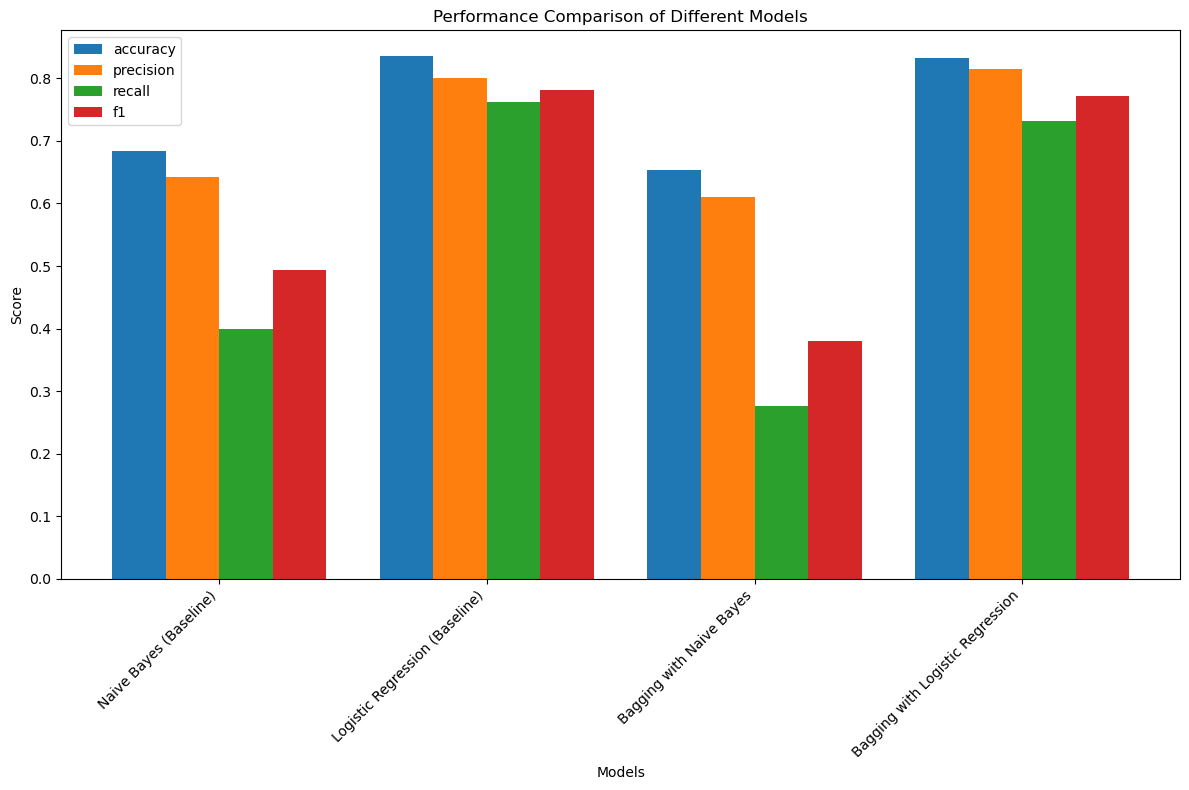

In [23]:
import numpy as np
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt

# Load the features if not already loaded
if 'X' not in locals() or 'y' not in locals():
    # Load from the saved features CSV
    df = pd.read_csv("extracted_features.csv")
    X = df.drop('label', axis=1).values
    y = df['label'].values
    
    # Normalize features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42, stratify=y)

# 1. Individual models for baseline comparison
print("Training individual models for baseline comparison...")

# Naive Bayes baseline
nb_baseline = GaussianNB()
nb_baseline.fit(X_train, y_train)
y_pred_nb = nb_baseline.predict(X_test)

# Logistic Regression baseline
lr_baseline = LogisticRegression(max_iter=1000, random_state=42)
lr_baseline.fit(X_train, y_train)
y_pred_lr = lr_baseline.predict(X_test)

# 2. Bagging with Naive Bayes
print("Training Bagging with Naive Bayes...")
bagging_nb = BaggingClassifier(
    estimator=GaussianNB(),
    n_estimators=10,
    max_samples=0.8,
    max_features=0.8,
    bootstrap=True,
    bootstrap_features=True,
    random_state=42
)
bagging_nb.fit(X_train, y_train)
y_pred_bagging_nb = bagging_nb.predict(X_test)

# 3. Bagging with Logistic Regression
print("Training Bagging with Logistic Regression...")
bagging_lr = BaggingClassifier(
    estimator=LogisticRegression(max_iter=1000),
    n_estimators=10,
    max_samples=0.8,
    max_features=0.8,
    bootstrap=True,
    bootstrap_features=True,
    random_state=42
)
bagging_lr.fit(X_train, y_train)
y_pred_bagging_lr = bagging_lr.predict(X_test)

# Evaluation function
def evaluate_model(y_true, y_pred, model_name):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)
    
    print(f"\n{model_name} Results:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    
    return {
        'model': model_name,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'confusion_matrix': cm
    }

# Evaluate all models
results = []
results.append(evaluate_model(y_test, y_pred_nb, "Naive Bayes (Baseline)"))
results.append(evaluate_model(y_test, y_pred_lr, "Logistic Regression (Baseline)"))
results.append(evaluate_model(y_test, y_pred_bagging_nb, "Bagging with Naive Bayes"))
results.append(evaluate_model(y_test, y_pred_bagging_lr, "Bagging with Logistic Regression"))

# Plot confusion matrices
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for i, result in enumerate(results):
    cm = result['confusion_matrix']
    ax = axes[i]
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    ax.set_title(result['model'])
    
    # Add text annotations to the confusion matrix
    thresh = cm.max() / 2
    for j in range(cm.shape[0]):
        for k in range(cm.shape[1]):
            ax.text(k, j, format(cm[j, k], 'd'),
                    ha="center", va="center",
                    color="white" if cm[j, k] > thresh else "black")
    
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Male', 'Female'])
    ax.set_yticklabels(['Male', 'Female'])
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

fig.tight_layout()
plt.colorbar(im, ax=axes.ravel().tolist())
plt.show()

# Plot performance comparison
metrics = ['accuracy', 'precision', 'recall', 'f1']
model_names = [r['model'] for r in results]

fig, ax = plt.subplots(figsize=(12, 8))
bar_width = 0.2
r = np.arange(len(model_names))

for i, metric in enumerate(metrics):
    values = [result[metric] for result in results]
    ax.bar(r + i * bar_width, values, width=bar_width, label=metric)

ax.set_xlabel('Models')
ax.set_xticks(r + bar_width * (len(metrics) - 1) / 2)
ax.set_xticklabels(model_names, rotation=45, ha='right')
ax.set_ylabel('Score')
ax.set_title('Performance Comparison of Different Models')
ax.legend()
plt.tight_layout()
plt.show()

Training Graphical Naive Bayes model...

Naive Bayes (Baseline) Results:
Accuracy: 0.6830
Precision: 0.6427
Recall: 0.3997
F1 Score: 0.4929

Logistic Regression (Baseline) Results:
Accuracy: 0.8348
Precision: 0.8000
Recall: 0.7619
F1 Score: 0.7805

Bagging with Naive Bayes Results:
Accuracy: 0.6529
Precision: 0.6095
Recall: 0.2771
F1 Score: 0.3810

Bagging with Logistic Regression Results:
Accuracy: 0.8326
Precision: 0.8151
Recall: 0.7316
F1 Score: 0.7711

Graphical Naive Bayes Results:
Accuracy: 0.6824
Precision: 0.6399
Recall: 0.4026
F1 Score: 0.4942


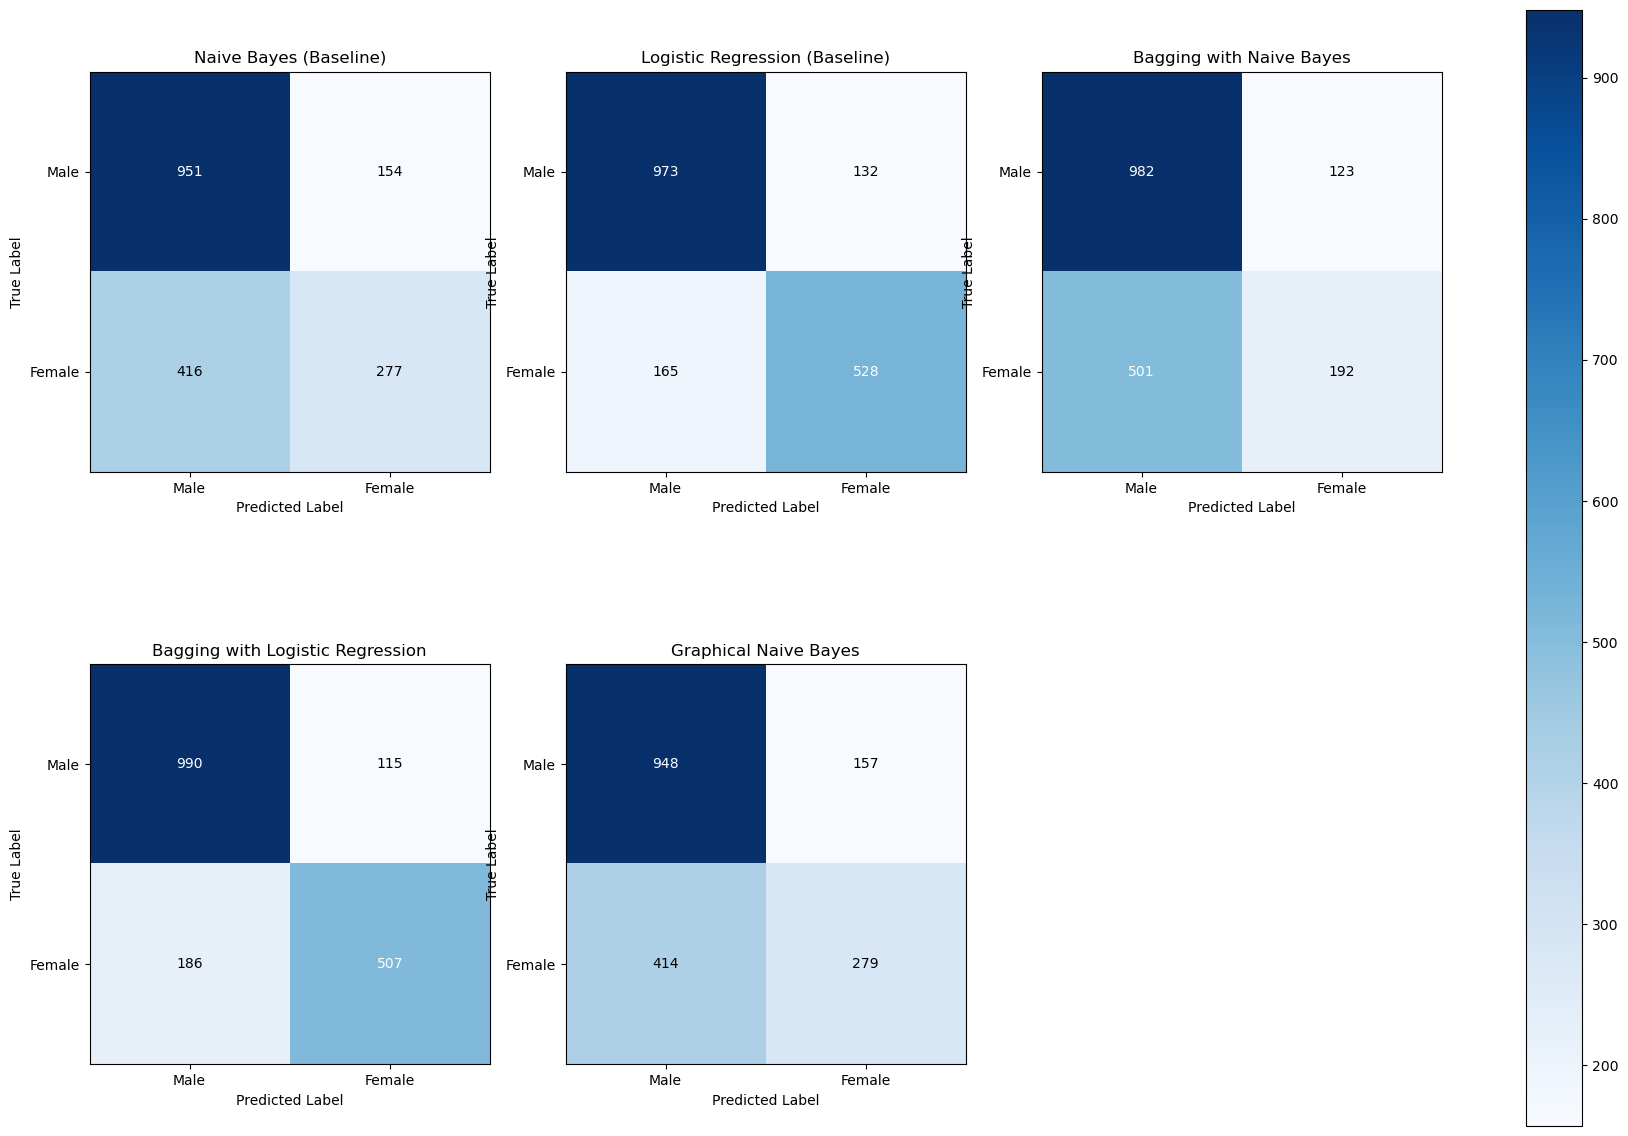

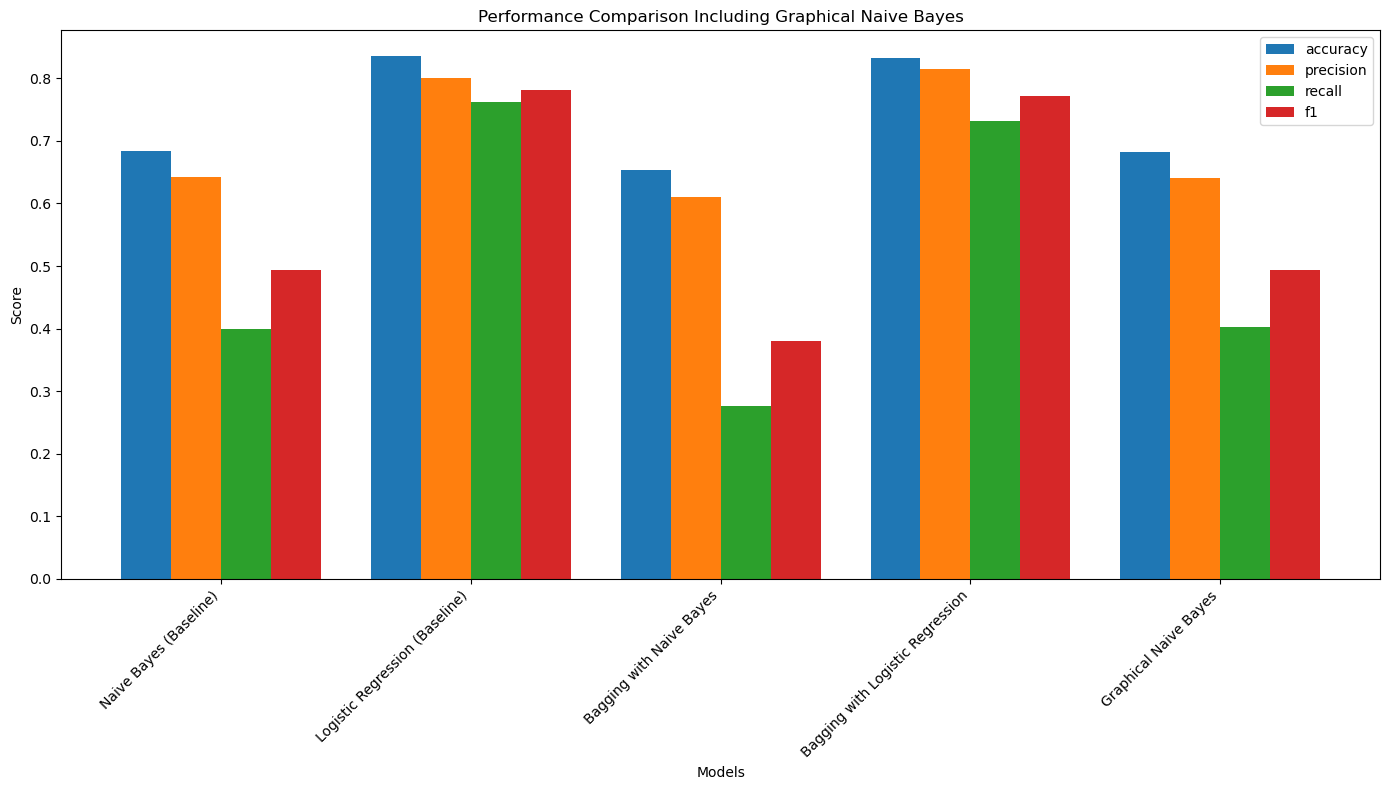

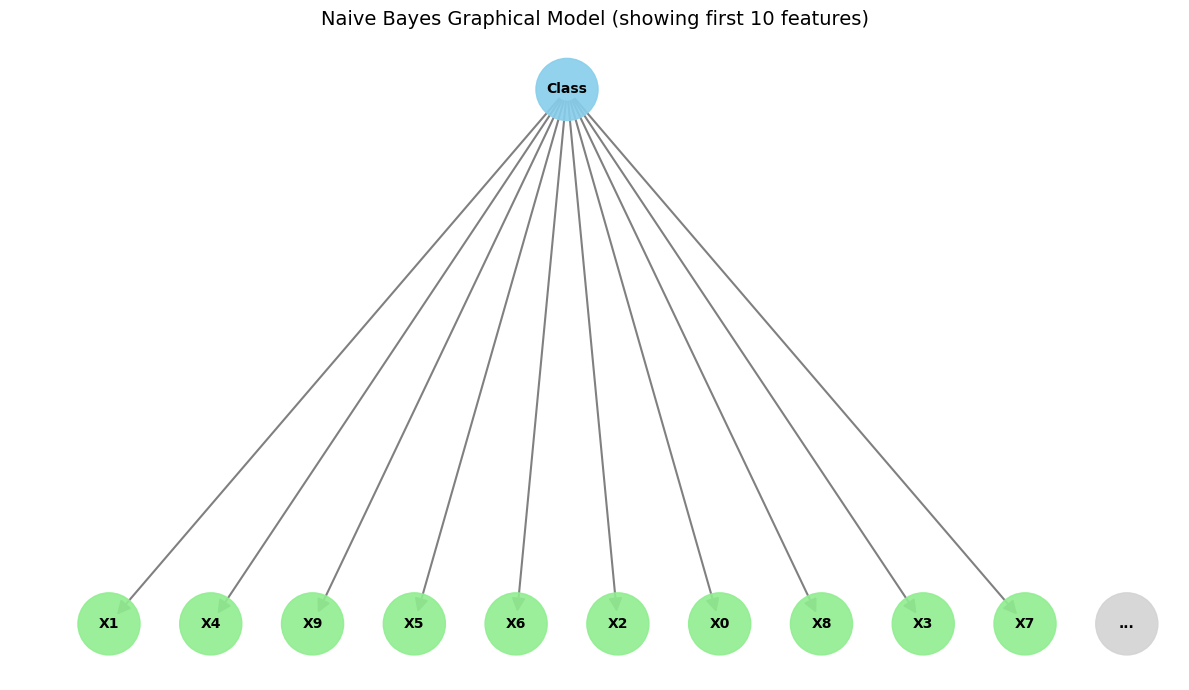

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Load the features if not already loaded
if 'X' not in locals() or 'y' not in locals():
    # Load from the saved features CSV
    df = pd.read_csv("extracted_features.csv")
    X = df.drop('label', axis=1).values
    y = df['label'].values
    
    # Normalize features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42, stratify=y)

# Implement our Graphical Naive Bayes model
print("Training Graphical Naive Bayes model...")
gnb_graph = NaiveBayesGraph()
gnb_graph.fit(X_train, y_train)
y_pred_gnb_graph = gnb_graph.predict(X_test)

# Evaluate all models
results = []

# Add previous results if they exist
if 'y_pred_nb' in locals():
    results.append(evaluate_model(y_test, y_pred_nb, "Naive Bayes (Baseline)"))
if 'y_pred_lr' in locals():
    results.append(evaluate_model(y_test, y_pred_lr, "Logistic Regression (Baseline)"))
if 'y_pred_bagging_nb' in locals():
    results.append(evaluate_model(y_test, y_pred_bagging_nb, "Bagging with Naive Bayes"))
if 'y_pred_bagging_lr' in locals():
    results.append(evaluate_model(y_test, y_pred_bagging_lr, "Bagging with Logistic Regression"))

# Add new model result
results.append(evaluate_model(y_test, y_pred_gnb_graph, "Graphical Naive Bayes"))

# Plot confusion matrices
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, result in enumerate(results):
    if i < len(axes):
        cm = result['confusion_matrix']
        ax = axes[i]
        im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
        ax.set_title(result['model'])
        
        # Add text annotations to the confusion matrix
        thresh = cm.max() / 2
        for j in range(cm.shape[0]):
            for k in range(cm.shape[1]):
                ax.text(k, j, format(cm[j, k], 'd'),
                        ha="center", va="center",
                        color="white" if cm[j, k] > thresh else "black")
        
        ax.set_xticks([0, 1])
        ax.set_yticks([0, 1])
        ax.set_xticklabels(['Male', 'Female'])
        ax.set_yticklabels(['Male', 'Female'])
        ax.set_xlabel('Predicted Label')
        ax.set_ylabel('True Label')

# Hide any unused subplots
for i in range(len(results), len(axes)):
    axes[i].axis('off')

fig.tight_layout()
plt.colorbar(im, ax=axes.ravel().tolist())
plt.show()

# Plot performance comparison
metrics = ['accuracy', 'precision', 'recall', 'f1']
model_names = [r['model'] for r in results]

fig, ax = plt.subplots(figsize=(14, 8))
bar_width = 0.2
r = np.arange(len(model_names))

for i, metric in enumerate(metrics):
    values = [result[metric] for result in results]
    ax.bar(r + i * bar_width, values, width=bar_width, label=metric)

ax.set_xlabel('Models')
ax.set_xticks(r + bar_width * (len(metrics) - 1) / 2)
ax.set_xticklabels(model_names, rotation=45, ha='right')
ax.set_ylabel('Score')
ax.set_title('Performance Comparison Including Graphical Naive Bayes')
ax.legend()
plt.tight_layout()
plt.show()

# Display the graphical model structure (if supported)
try:
    gnb_graph.visualize()
except:
    print("Could not visualize the graphical model structure")


## Test the Gender Voice Classifier 

In [31]:
import sounddevice as sd
import soundfile as sf
import numpy as np
import threading
from tkinter import messagebox, Tk, Button, Label, Frame
import os
import time
import networkx as nx
import networkx as nx

import matplotlib.pyplot as plt

# Variables for recording
recording = False
file_exists = False
recorded_file = "recorded_audio.wav"
sample_rate = 44100
duration = 3  # seconds to record

# Recording function
def record_audio():
    global recording, file_exists
    recording = True
    print("Recording...")
    
    # Record audio
    audio_data = sd.rec(int(duration * sample_rate), samplerate=sample_rate, channels=1)
    
    # Wait until recording is finished
    while recording:
        sd.wait()
        break
    
    # Save the recorded audio
    if recording:  # If recording wasn't stopped manually
        sf.write(recorded_file, audio_data, sample_rate)
        file_exists = True
        print("Recording saved to", recorded_file)
    
    recording = False

# Function to handle recording as a thread
def threading_rec(x):
    if x == 1:
        # If recording is selected, then the thread is activated
        t1 = threading.Thread(target=record_audio)
        t1.start()
    elif x == 2:
        # To stop, set the flag to false
        global recording
        recording = False
        messagebox.showinfo(message="Recording finished")
    elif x == 3:
        # To play a recording, it must exist
        if file_exists:
            # Read the recording if it exists and play it
            data, fs = sf.read(recorded_file, dtype='float32')
            sd.play(data, fs)
            sd.wait()
        else:
            # Display an error if none is found
            messagebox.showerror(message="Record something to play")

# Function to classify gender from audio file
def classify_gender(file_path):
    # Extract features using the existing function
    features = extract_features(file_path)
    
    if features is None:
        return "Error extracting features"
    
    # Scale features using the existing scaler
    features_scaled = scaler.transform(features.reshape(1, -1))
    
    # Get predictions from all models
    results = {}
    
    # 1. Standard Naive Bayes
    if 'nb_baseline' in globals():
        pred_nb = nb_baseline.predict(features_scaled)[0]
        prob_nb = nb_baseline.predict_proba(features_scaled)[0]
        gender_nb = "Female" if pred_nb == 1 else "Male"
        confidence_nb = prob_nb[pred_nb]
        results["Naive Bayes"] = (gender_nb, confidence_nb)
    
    # 2. Logistic Regression
    if 'lr_baseline' in globals():
        pred_lr = lr_baseline.predict(features_scaled)[0]
        prob_lr = lr_baseline.predict_proba(features_scaled)[0]
        gender_lr = "Female" if pred_lr == 1 else "Male"
        confidence_lr = prob_lr[pred_lr]
        results["Logistic Regression"] = (gender_lr, confidence_lr)
    
    # 3. Bagging with Naive Bayes
    if 'bagging_nb' in globals():
        pred_bag_nb = bagging_nb.predict(features_scaled)[0]
        prob_bag_nb = bagging_nb.predict_proba(features_scaled)[0]
        gender_bag_nb = "Female" if pred_bag_nb == 1 else "Male"
        confidence_bag_nb = prob_bag_nb[pred_bag_nb]
        results["Bagging with Naive Bayes"] = (gender_bag_nb, confidence_bag_nb)
    
    # 4. Bagging with Logistic Regression
    if 'bagging_lr' in globals():
        pred_bag_lr = bagging_lr.predict(features_scaled)[0]
        prob_bag_lr = bagging_lr.predict_proba(features_scaled)[0]
        gender_bag_lr = "Female" if pred_bag_lr == 1 else "Male"
        confidence_bag_lr = prob_bag_lr[pred_bag_lr]
        results["Bagging with Logistic Regression"] = (gender_bag_lr, confidence_bag_lr)
    
    # 5. Graphical Naive Bayes
    if 'gnb_graph' in globals():
        pred_gnb_graph = gnb_graph.predict(features_scaled)[0]
        prob_gnb_graph = gnb_graph.predict_proba(features_scaled)[0][pred_gnb_graph]
        gender_gnb_graph = "Female" if pred_gnb_graph == 1 else "Male"
        results["Graphical Naive Bayes"] = (gender_gnb_graph, prob_gnb_graph)
    
    return results

# GUI for audio recording and classification
def create_gui():
    # Create root window
    root = Tk()
    root.title("Gender Voice Classifier")
    root.geometry("600x400")
    
    # Create frames
    record_frame = Frame(root)
    record_frame.pack(pady=20)
    
    result_frame = Frame(root)
    result_frame.pack(pady=20, fill='both', expand=True)
    
    # Recording controls
    Label(record_frame, text="Record your voice for gender classification:", font=("Arial", 12)).pack()
    
    Button(record_frame, text="Record", command=lambda: threading_rec(1), bg="#4CAF50", fg="white", padx=10).pack(side='left', padx=5)
    Button(record_frame, text="Stop", command=lambda: threading_rec(2), bg="#F44336", fg="white", padx=10).pack(side='left', padx=5)
    Button(record_frame, text="Play", command=lambda: threading_rec(3), bg="#2196F3", fg="white", padx=10).pack(side='left', padx=5)
    
    # Classification button
    Button(record_frame, text="Classify Gender", command=lambda: show_results(result_label), 
           bg="#9C27B0", fg="white", padx=10).pack(side='left', padx=10)
    
    # Results area
    result_label = Label(result_frame, text="Record your voice and click 'Classify Gender'", 
                         font=("Arial", 11), justify='left', wraplength=550)
    result_label.pack(fill='both', expand=True)
    
    root.mainloop()

# Function to display classification results
def show_results(label):
    if not file_exists:
        label.config(text="Please record audio first")
        return
    
    # Show a "processing" message
    label.config(text="Analyzing voice... please wait.")
    label.update()
    
    # Get classification results
    results = classify_gender(recorded_file)
    
    if isinstance(results, str):
        label.config(text=results)
        return
    
    # Format results for display
    result_text = "Gender Classification Results:\n\n"
    
    # Count predictions
    male_votes = 0
    female_votes = 0
    
    for model, (gender, confidence) in results.items():
        result_text += f"{model}: {gender} (confidence: {confidence:.2f})\n"
        if gender == "Male":
            male_votes += 1
        else:
            female_votes += 1
    
    # Add a final consensus
    result_text += f"\nConsensus: {'Male' if male_votes > female_votes else 'Female'} ({max(male_votes, female_votes)}/{male_votes+female_votes} models agree)"
    
    # Update the label
    label.config(text=result_text)

# Start the GUI
if __name__ == "__main__":
    # Make sure networkx is imported if not already
    if 'nx' not in globals():
        
        create_gui()

OSError: cannot load library 'libportaudio.so.2': /home/ammarmorad/anaconda3/lib/python3.12/site-packages/zmq/backend/cython/../../../../.././libstdc++.so.6: version `GLIBCXX_3.4.32' not found (required by /lib/x86_64-linux-gnu/libjack.so.0)